## Mission 4 - Predicting House Price with Multiple Linear Regression

Introduction
In this mission, you will be working with a real estate dataset to perform Exploratory Data Analysis (EDA) and create a Multiple Linear Regression (MLR) model to predict the Price of a house based on various features such as Square Feet, Number of Bedrooms, Number of Bathrooms, and other factors.

The dataset includes the following columns:

**Square_Feet:** The total area of the house in square feet.

**Num_Bedrooms:** The number of bedrooms in the house.

**Num_Bathrooms:** The number of bathrooms in the house.

**Num_Floors:** The number of floors in the house.

**Garage_Size:** The size of the garage.

**Location_Score:** A score representing the desirability of the location.

**Distance_to_Center:** The distance (in km) to the city center.

**Price:** The price of the house (target variable).


## Step 1: Loading and Understanding the Data

Start by loading the dataset into a Pandas DataFrame. Inspect the first few rows of the dataset and understand its structure.

Tasks:

Task 1.1. The data is stored in Azure Blob Storage. To connect to Azure Blob Storage, we will use a connection string that contains authentication details such as the account name and account key. See the credentials below.


Task 1.2. Load the dataset into a Pandas DataFrame from the CSV file stored in Blob Storage. Name the dataframe as df_house_price

Task 1.3. Display the first few rows.

Task 1.4. Check the data types and null values.

In [2]:
connect_str = "DefaultEndpointsProtocol=https;AccountName=level5data;AccountKey=cWgxWhPELQdrW0sIgA/eXM8/k9+xdaELukN8sg5imfhm4wVIJQFmypEph/Ppy500v41mYT+iCBbC+AStsfHbAQ==;EndpointSuffix=core.windows.net"
container_name = "businesscases"
blob_name = "house_sales_prediction.csv"

In [3]:
###The data is stored in Azure Blob Storage. To connect to Azure Blob Storage, we will use a connection string that contains authentication details such as the account name and account key. See the credentials below

import pandas as pd
from azure.storage.blob import BlobServiceClient
from io import StringIO

connect_str = "DefaultEndpointsProtocol=https;AccountName=level5data;AccountKey=cWgxWhPELQdrW0sIgA/eXM8/k9+xdaELukN8sg5imfhm4wVIJQFmypEph/Ppy500v41mYT+iCBbC+AStsfHbAQ==;EndpointSuffix=core.windows.net"
container_name = "businesscases"
blob_name = "house_sales_prediction.csv"

blob_service_client = BlobServiceClient.from_connection_string(connect_str)

container_client = blob_service_client.get_container_client(container_name)

blob_client = container_client.get_blob_client(blob_name)

blob_data = blob_client.download_blob()
csv_content = blob_data.readall().decode('utf-8')

df_house_price = pd.read_csv(StringIO(csv_content))

display(df_house_price)


In [4]:
### Task 1.3. Display the first few rows.

df_house_price.head(10)


,Square_Feet,Num_Bedrooms,Num_Bathrooms,Num_Floors,Garage_Size,Location_Score,Distance_to_Center,Price
0,143.635030,1,3,3,48,8.297631,5.935734,602134.8167
1,287.678577,1,2,1,37,6.061466,10.827392,591425.1354
2,232.998485,1,3,2,14,2.911442,6.904599,464478.6969
3,199.664621,5,2,2,17,2.070949,8.284019,583105.6560
4,89.004660,4,3,3,34,1.523278,14.648277,619879.1425
5,88.998630,5,3,2,36,8.994552,17.633250,670386.8044
6,64.520903,4,3,1,32,7.101354,2.429908,523827.1256
7,266.544036,5,1,3,39,9.373784,12.692785,875352.5452
8,200.278753,5,1,1,32,6.032918,11.642876,738269.8523
9,227.018144,3,2,1,29,4.734009,2.368301,490552.6812


In [5]:
###Task 1.4. Check the data types and null values

print("Data Types:")
display(df_house_price.dtypes)

print("Null Values:")
display(df_house_price.isnull().sum())

Data Types:


Null Values:


## Step 2: Exploratory Data Analysis (EDA)

In this step, you will perform some basic EDA to understand the relationships between the features and the target variable (Price). This includes visualising the data, checking for correlations, and identifying patterns.

Tasks:

Task 2.1. Check summary statistics for the dataset.

Task 2.2. Visualise the relationship between Square Feet and Price using a scatter plot.

Task 2.3.  Visualise the distribution of the Price variable using a histogram.

Task 2.4.  Compute and visualize the correlation matrix between the features.

Task 2.5. Write 1–2 sentences explaining the insights from each visualisation.

In [6]:
### Check summary statistics for the dataset

df_house_price.describe()

,Square_Feet,Num_Bedrooms,Num_Bathrooms,Num_Floors,Garage_Size,Location_Score,Distance_to_Center,Price
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,174.640428,2.958000,1.976000,1.964000,30.174000,5.164410,10.469641,582209.629531
std,74.672102,1.440968,0.820225,0.802491,11.582575,2.853489,5.588197,122273.390347
min,51.265396,1.000000,1.000000,1.000000,10.000000,0.004428,0.062818,276892.470100
25%,110.319923,2.000000,1.000000,1.000000,20.000000,2.760650,6.066754,503080.344175
50%,178.290937,3.000000,2.000000,2.000000,30.000000,5.206518,10.886066,574724.113350
75%,239.031220,4.000000,3.000000,3.000000,41.000000,7.732933,15.072590,665942.301300
max,298.241199,5.000000,3.000000,3.000000,49.000000,9.995439,19.927966,960678.274300


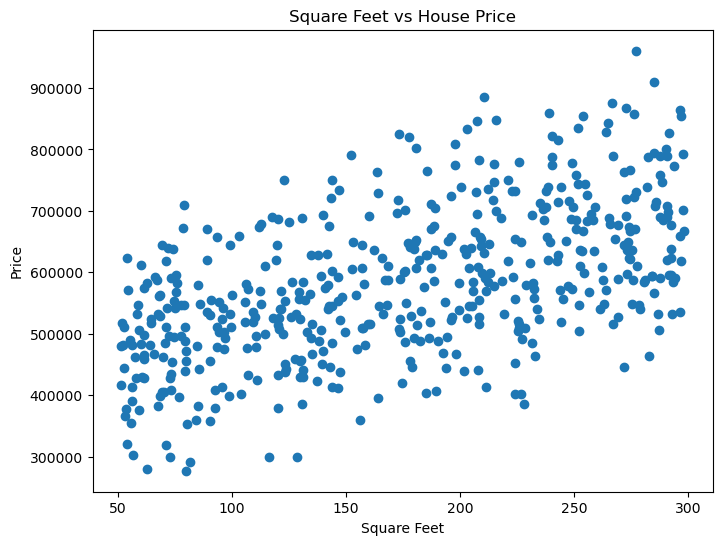

In [7]:
### Visualise the relationship between Square Feet and Price using a scatter plot.

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(df_house_price["Square_Feet"], df_house_price["Price"])

plt.title("Square Feet vs House Price")
plt.xlabel("Square Feet")
plt.ylabel("Price")
plt.show()

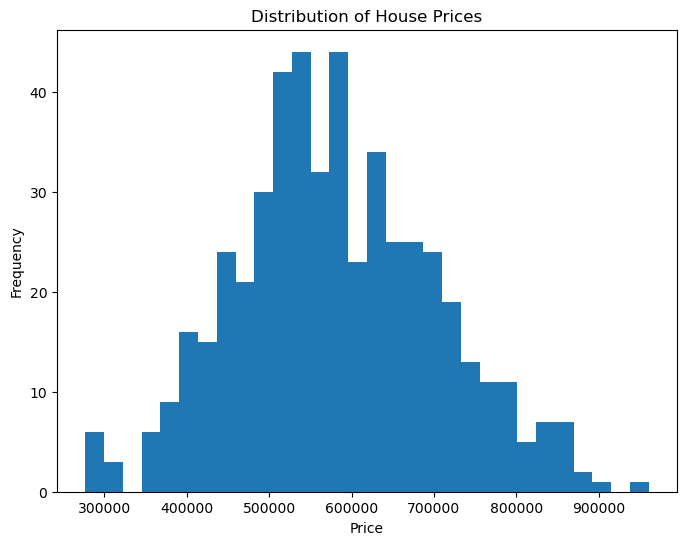

In [8]:
### Visualise the distribution of the Price variable using a histogram.

plt.figure(figsize=(8, 6))
plt.hist(df_house_price["Price"], bins=30)

plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 10.8 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


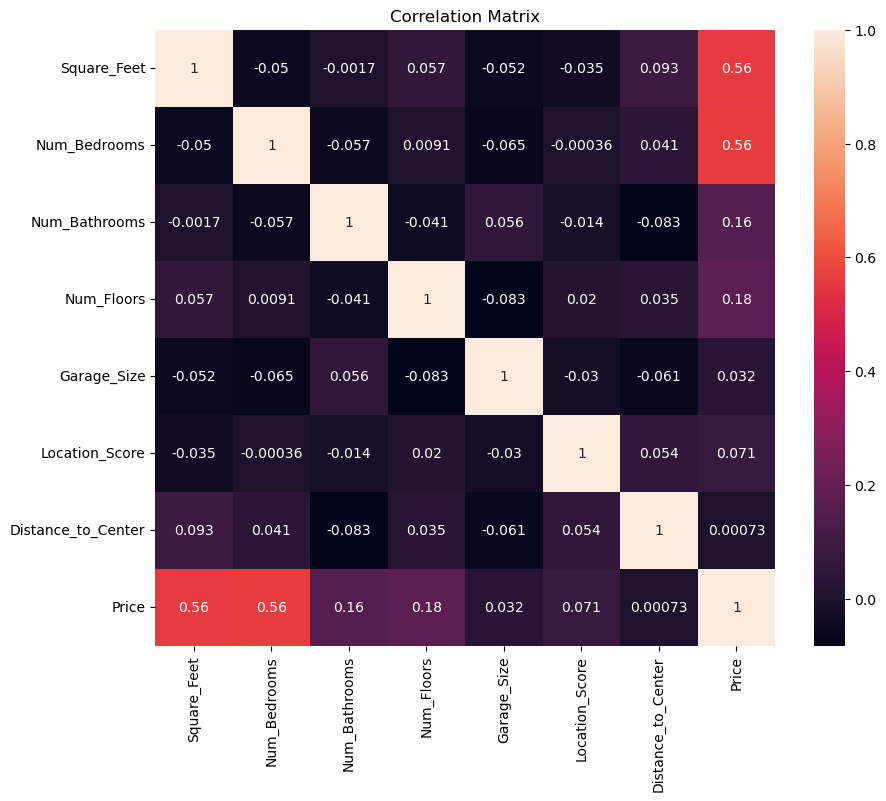

In [9]:
###  Compute and visualize the correlation matrix between the features.

%pip install seaborn

import seaborn as sns

correlation_matrix = df_house_price.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True)

plt.title("Correlation Matrix")
plt.show()

In [10]:
### Write 1–2 sentences explaining the insights from each visualisation.

### Scatter Plot:
### The scatter plot shows a positive relationship between Square Feet and Price. 
### In general, larger houses tend to have higher prices, although there is variation in the data.

### Histogram:
### The histogram shows that most house prices are concentrated around the middle price ranges,
### with fewer houses at the very low and very high ends.

### Correlation Matrix:
### The correlation matrix shows that Square Feet and Number of Bedrooms have the strongest
### positive relationships with Price, both with correlations of approximately 0.56.

## Step 3: Creating a Multiple Linear Regression (MLR) Model

In this step, we will use Multiple Linear Regression to predict the Price of the house based on the features. We will split the data into a training set and a testing set, fit the model, and evaluate its performance.

Task 3.1: Split the Data into Features and Target
Split the dataset into features (X) and target variable (y).

Task 3.2: Split the Data into Training and Testing Sets
Split the data into training (80%) and testing (20%) sets.

Task 3.3: Train the Multiple Linear Regression Model
Train the Multiple Linear Regression (MLR) model using the training data.

Task 3.4: Visualise the Predicted vs Actual Prices
Create a scatter plot comparing the actual prices and predicted prices for the test set.

Task 3.5: Evaluate the Model
Evaluate the model using Root Mean Squared Error (RMSE) and interpret the results.

Task 3.6. Write 1–2 sentences explaining the insights from the visualisation.

In [11]:
####  Split the Data into Features and Target Split the dataset into features (X) and target variable (y)

X = df_house_price[['Square_Feet', 'Num_Bedrooms', 'Num_Bathrooms', 'Num_Floors', 'Garage_Size', 'Location_Score', 'Distance_to_Center']]
y = df_house_price['Price']

In [12]:
### Split the Data into Training and Testing Sets Split the data into training (80%) and testing (20%) sets

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training Data: {X_train.shape}, Testing Data: {X_test.shape}")


Training Data: (400, 7), Testing Data: (100, 7)


In [13]:
### Train the Multiple Linear Regression Model Train the Multiple Linear Regression (MLR) model using the training data

from sklearn.linear_model import LinearRegression

model_lr = LinearRegression()

model_lr.fit(X_train, y_train)

y_pred_lr = model_lr.predict(X_test)


🏃 View run crimson_kitchen_24p00wyy at: https://2d0fc43f898c4b4fa153ed44d311104c.pbidedicated.windows.net/webapi/capacities/2d0fc43f-898c-4b4f-a153-ed44d311104c/workloads/ML/ML/Automatic/workspaceid/6c3542a9-925a-421b-92ba-bd708fe5172d/#/experiments/f0b62bd9-c1ba-4d4e-b2ee-d59198e0c4f5/runs/93d8051c-fc86-4323-b831-fae256320852
🧪 View experiment at: https://2d0fc43f898c4b4fa153ed44d311104c.pbidedicated.windows.net/webapi/capacities/2d0fc43f-898c-4b4f-a153-ed44d311104c/workloads/ML/ML/Automatic/workspaceid/6c3542a9-925a-421b-92ba-bd708fe5172d/#/experiments/f0b62bd9-c1ba-4d4e-b2ee-d59198e0c4f5


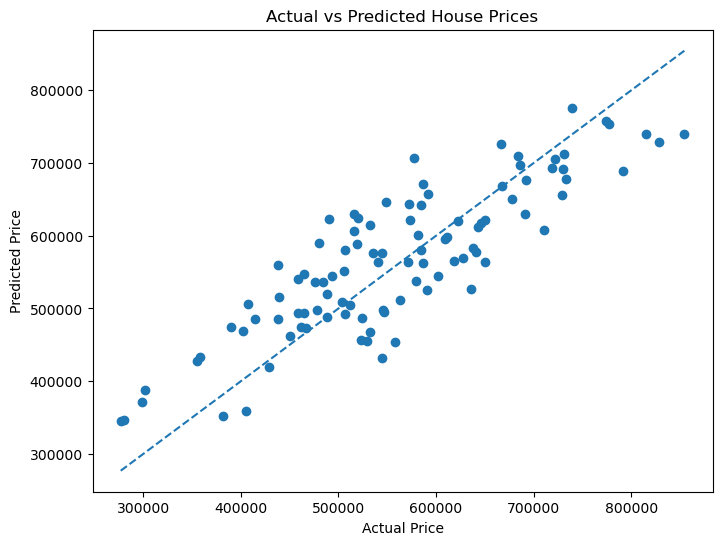

In [14]:
###Visualise the Predicted vs Actual Prices Create a scatter plot comparing the actual prices and predicted prices for the test set.

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred_lr)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle='--')

plt.show()

In [15]:
### Evaluate the Model Evaluate the model using Root Mean Squared Error (RMSE) and interpret the results

from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))

print(f"Root Mean Squared Error (RMSE) for MLR: {rmse}")

Root Mean Squared Error (RMSE) for MLR: 63952.37599755184


In [16]:
### Write 1–2 sentences explaining the insights from the visualisation

 ### The graph shows that the predicted prices generally follow the actual house prices, with most points showing a similar upward pattern. 
 ### However, some predictions are quite different from the actual prices, which is also reflected in the RMSE of about $63,952.  

## Step 4: Compare with Random Forest Regressor

Task 4.1: Train a Random Forest Model
Train a Random Forest Regressor model and evaluate its performance.

Task 4.2: Visualise Actual vs Predicted Prices for Random Forest
Create a scatter plot comparing the actual prices and predicted prices for the Random Forest model.

Task 4.3: Model Comparison
Compare the RMSE values of both the MLR and Random Forest models. Which model performs better?

In [17]:
### Train a Random Forest Model Train a Random Forest Regressor model and evaluate its performance.

from sklearn.ensemble import RandomForestRegressor

# Create the Random Forest model
model_rf = RandomForestRegressor(n_estimators=100, random_state=42)

# Train the model using the training data
model_rf.fit(X_train, y_train)

# Predict house prices using the test data
y_pred_rf = model_rf.predict(X_test)

🏃 View run elated_hominy_4xg4jzt3 at: https://2d0fc43f898c4b4fa153ed44d311104c.pbidedicated.windows.net/webapi/capacities/2d0fc43f-898c-4b4f-a153-ed44d311104c/workloads/ML/ML/Automatic/workspaceid/6c3542a9-925a-421b-92ba-bd708fe5172d/#/experiments/f0b62bd9-c1ba-4d4e-b2ee-d59198e0c4f5/runs/52e2939b-a0f8-4910-b352-f5de77a2c516
🧪 View experiment at: https://2d0fc43f898c4b4fa153ed44d311104c.pbidedicated.windows.net/webapi/capacities/2d0fc43f-898c-4b4f-a153-ed44d311104c/workloads/ML/ML/Automatic/workspaceid/6c3542a9-925a-421b-92ba-bd708fe5172d/#/experiments/f0b62bd9-c1ba-4d4e-b2ee-d59198e0c4f5


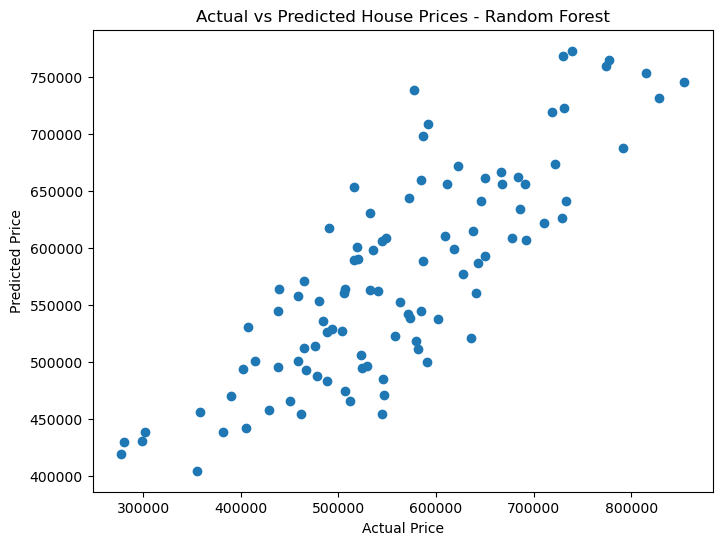

In [18]:
### Visualise Actual vs Predicted Prices for Random Forest 
### Create a scatter plot comparing the actual prices and predicted prices for the Random Forest model.

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_rf)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices - Random Forest")
plt.show()

In [19]:
### Calculate RMSE for the Random Forest model

from sklearn.metrics import mean_squared_error
import numpy as np

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print("Random Forest RMSE:", rmse_rf)

Random Forest RMSE: 71733.35944826744


In [20]:
### Compare Multiple Linear Regression and Random Forest

print("Multiple Linear Regression RMSE:", rmse)
print("Random Forest RMSE:", rmse_rf)

### From the results below, the Multiple Linear Regression model has a lower RMSE (63,952.38) than the Random Forest model (71,733.36).

### We can therefore conclude that the Multiple Linear Regression model performed better on the test data.

Multiple Linear Regression RMSE: 63952.37599755184
Random Forest RMSE: 71733.35944826744


## Step 5: Conclusion and Insights

Task 5.1: Insights and Recommendations

Based on the RMSE and visualisations, summarise which model performs better and why.

Discuss any improvements that could be made to both models.

### The Multiple Linear Regression model performed better than the Random Forest model because its RMSE was lower at 63,952.38, compared with 71,733.36 for Random Forest. This shows that the MLR predictions were closer to the actual house prices in this dataset.

### From the graphs, both models were able to follow the general pattern of the actual house prices, but there were still some differences between the actual and predicted values.

### TThe models could be improved by adding more information about the houses, such as their condition, neighbourhood and age. I could also check for outliers in the data and try different settings for the Random Forest model, such as the number of trees and tree depth, to see if the predictions improve.